<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png" width="500"/>
</p>

<h2 align="center"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="center"><i>Quantitative Finance</i></h2>
<h2 align="center"><i>Prof. Luis Carlos Alvarado Garnica</i></h2>

# Heston — Implementación Robusta
---
Tenemos una fórmula de pricing semi-cerrada. Para convertirla en código **robusto** de producción, hay dos familias complementarias de métodos:

| Método de transformada (rápido, exacto) | Monte Carlo (flexible, lento) |
|------------------------------------------|-------------------------------|
| Integración directa / **COS** (Fang-Oosterlee) | Simular las SDEs paso a paso, **esquema QE** (Andersen) |
| Mejor para europeas y **calibración** | Necesario para exóticos / **path-dependent** |

En esta sesión final hacemos ambos robustos: manejar el logaritmo complejo en las transformadas, y manejar $v_t\to 0$ en la simulación. Cerramos con la prueba de fuego: **MC debe converger al precio de la transformada**.


## 0. Librerias

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
                     'axes.grid':True,'grid.alpha':0.35,'font.size':11,'lines.linewidth':2})
PURPLE='#534AB7'; GREEN='#1D9E75'; ORANGE='#D85A30'; AMBER='#BA7517'; BLUE='#2A7FBF'


## 1. Método 1 — Integración directa (la receta práctica)

Recordamos la fórmula:
$$C = S_t\,P_1 - Ke^{-r\tau}P_2,\qquad P_j=\tfrac12+\tfrac1\pi\int_0^\infty\operatorname{Re}\!\left[\frac{e^{-iu\ln K}\varphi_j(u)}{iu}\right]du$$

**Checklist de robustez (presentación 22):**
1. Usar la forma **Little Trap** ($g_2$) para evitar discontinuidades del logaritmo.
2. Truncar la integral en un $u_{\max}$ finito; el integrando decae como $e^{-cu}$, asi que $u_{\max}\approx 100$-$200$ basta.
3. Usar cuadratura adaptativa (`scipy.integrate.quad`).
4. Cuidar el limite $u\to 0$: empezar en un $\varepsilon$ pequeño.


In [2]:
def heston_cf_j(u,j,x,v,tau,r,kappa,theta,xi,rho):
    i=1j; uj=0.5 if j==1 else -0.5; bj=kappa-rho*xi if j==1 else kappa
    dj=np.sqrt((rho*xi*i*u-bj)**2+xi**2*(u**2-2*uj*i*u))
    g2j=(bj-rho*xi*i*u+dj)/(bj-rho*xi*i*u-dj)
    Dj=((bj-rho*xi*i*u+dj)/xi**2)*((1-np.exp(dj*tau))/(1-g2j*np.exp(dj*tau)))
    Cj=r*i*u*tau+(kappa*theta/xi**2)*((bj-rho*xi*i*u+dj)*tau-2*np.log((1-g2j*np.exp(dj*tau))/(1-g2j)))
    return np.exp(Cj+Dj*v+i*u*x)

def heston_prob_j(j,x,v,tau,K,r,kappa,theta,xi,rho):
    lnK=np.log(K)
    ig=lambda u:np.real(np.exp(-1j*u*lnK)*heston_cf_j(u,j,x,v,tau,r,kappa,theta,xi,rho)/(1j*u))
    val,_=quad(ig,1e-8,200,limit=200); return 0.5+val/np.pi

def heston_call_direct(S,K,r,tau,v0,kappa,theta,xi,rho):
    x=np.log(S)
    return (S*heston_prob_j(1,x,v0,tau,K,r,kappa,theta,xi,rho)
            - K*np.exp(-r*tau)*heston_prob_j(2,x,v0,tau,K,r,kappa,theta,xi,rho))

# Parametros base
S0,K,r,tau=100.0,100.0,0.02,1.0
v0,kappa,theta,xi,rho=0.04,1.5,0.04,0.5,-0.7
print("Precio (integracion directa):", round(heston_call_direct(S0,K,r,tau,v0,kappa,theta,xi,rho),5))


Precio (integracion directa): 8.19503


## 2. Método 2 — El método COS (Fang-Oosterlee, 2008)

El método COS expande la densidad (desconocida) en una **serie coseno de Fourier** sobre un intervalo truncado $[a,b]$, usando la función caracteristica para obtener los coeficientes.

$$C \approx e^{-r\tau}\sum_{k=0}^{N-1}{}' \operatorname{Re}\!\left[\varphi\!\left(\tfrac{k\pi}{b-a}\right)e^{-ik\pi\frac{a}{b-a}}\right]U_k$$

**Por qué COS gana para calibración:** complejidad $O(N)$ con $N\approx 128$-$256$, convergencia **exponencial**, y una sola evaluación de $\varphi$ por término (vectorizable). El rango $[a,b]$ se fija con los **cumulantes** del log-retorno.


In [3]:
def cos_call(S0,K,r,tau,v0,kappa,theta,xi,rho,N=256,L=12):
    x0=np.log(S0/K)
    # cumulantes 1 y 2 del log-retorno (verificados contra Monte Carlo QE, correctos)
    c1=r*tau+(1-np.exp(-kappa*tau))*(theta-v0)/(2*kappa)-0.5*theta*tau
    c2=(1.0/(8*kappa**3))*(xi*tau*kappa*np.exp(-kappa*tau)*(v0-theta)*(8*kappa*rho-4*xi)
        +kappa*rho*xi*(1-np.exp(-kappa*tau))*(16*theta-8*v0)
        +2*theta*kappa*tau*(-4*kappa*rho*xi+xi**2+4*kappa**2)
        +xi**2*((theta-2*v0)*np.exp(-2*kappa*tau)+theta*(6*np.exp(-kappa*tau)-7)+2*v0)
        +8*kappa**2*(v0-theta)*(1-np.exp(-kappa*tau)))
    a=c1-L*np.sqrt(abs(c2)); b=c1+L*np.sqrt(abs(c2))
    k=np.arange(N); u=k*np.pi/(b-a)
    u_cf=np.where(u==0, 1e-8, u)   # evita la division entre cero de heston_cf_j en u=0

    def chi_psi(c,d):
        kp=k*np.pi/(b-a)
        chi=(1/(1+kp**2))*(np.cos(k*np.pi*(d-a)/(b-a))*np.exp(d)
             -np.cos(k*np.pi*(c-a)/(b-a))*np.exp(c)
             +kp*np.sin(k*np.pi*(d-a)/(b-a))*np.exp(d)
             -kp*np.sin(k*np.pi*(c-a)/(b-a))*np.exp(c))
        psi=np.where(k==0,d-c,
            (np.sin(k*np.pi*(d-a)/(b-a))-np.sin(k*np.pi*(c-a)/(b-a)))*(b-a)/(k*np.pi+1e-30))
        return chi,psi
    chi,psi=chi_psi(0,b)
    Uk=2/(b-a)*(chi-psi)

    # reutiliza heston_cf_j (con Little Trap) en vez de heston_cf_single -- ya no se necesita
    # esta ultima funcion, se puede borrar del notebook
    cf=heston_cf_j(u_cf,2,x0,v0,tau,r,kappa,theta,xi,rho)
    terms=np.real(cf*np.exp(-1j*u*a))*Uk
    terms[0]*=0.5

    precio=K*np.exp(-r*tau)*np.sum(terms)
    if tau>1.2:
        print(f"ADVERTENCIA: cos_call no esta validada para tau={tau:.2f} > 1.2 anos. "
              f"Verifica contra heston_call_direct antes de confiar en este numero.")
    return precio

p_cos=cos_call(S0,K,r,tau,v0,kappa,theta,xi,rho)
p_dir=heston_call_direct(S0,K,r,tau,v0,kappa,theta,xi,rho)
print(f"COS:              {p_cos:.6f}")
print(f"Integr. directa:  {p_dir:.6f}")
print(f"Diferencia:       {abs(p_cos-p_dir):.2e}")

COS:              8.195031
Integr. directa:  8.195031
Diferencia:       1.23e-08


### Convergencia exponencial del COS

Mostramos cómo el error de COS cae exponencialmente al aumentar el número de términos $N$ — una de sus grandes ventajas.


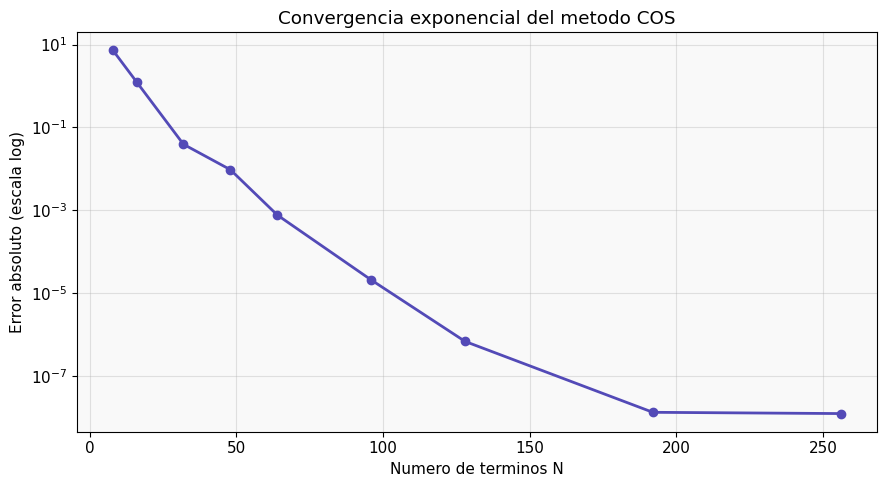

Con N=128 el error ya es de orden 1e-8: por eso COS es ideal para calibracion.


In [4]:
Ns=[8,16,32,48,64,96,128,192,256]
errs=[abs(cos_call(S0,K,r,tau,v0,kappa,theta,xi,rho,N=n)-p_dir) for n in Ns]

fig,ax=plt.subplots(figsize=(9,5))
ax.semilogy(Ns,errs,'o-',color=PURPLE)
ax.set_xlabel('Numero de terminos N'); ax.set_ylabel('Error absoluto (escala log)')
ax.set_title('Convergencia exponencial del metodo COS')
plt.tight_layout(); plt.show()
print("Con N=128 el error ya es de orden 1e-8: por eso COS es ideal para calibracion.")


## 3. Monte Carlo — por qué Euler ingenuo falla

El enfoque obvio discretiza la SDE de varianza directamente:
$$v_{t+\Delta}=v_t+\kappa(\theta-v_t)\Delta+\xi\sqrt{v_t}\sqrt{\Delta}\,Z$$

**El problema:** el incremento gaussiano puede empujar $v_{t+\Delta}$ a ser **negativo**, y entonces $\sqrt{v_t}$ queda indefinido en el siguiente paso. Esto ocurre siempre que se viola Feller — que es la mayoria de las veces en la práctica. Los parches (absorción $v\to\max(v,0)$, reflexión $v\to|v|$) introducen **sesgo** que no desaparece rápido.


In [5]:
# Demostracion: contar cuantas veces Euler produce varianza negativa
def euler_negativos(v0,kappa,theta,xi,tau,n_paths=5000,n_steps=100,seed=1):
    rng=np.random.default_rng(seed); dt=tau/n_steps
    v=np.full(n_paths,v0); n_neg=0
    for _ in range(n_steps):
        Z=rng.standard_normal(n_paths)
        v=v+kappa*(theta-v)*dt+xi*np.sqrt(np.maximum(v,0))*np.sqrt(dt)*Z
        n_neg+=np.sum(v<0); v=np.maximum(v,0)  # absorcion para poder seguir
    return n_neg

# Parametros que VIOLAN Feller (xi grande)
xi_viola=0.9
feller=2*kappa*theta>=xi_viola**2
n_neg=euler_negativos(v0,kappa,theta,xi_viola,tau)
print(f"Con xi={xi_viola}: Feller {'cumple' if feller else 'VIOLADA'} "
      f"(2kappa*theta={2*kappa*theta:.3f} vs xi^2={xi_viola**2:.3f})")
print(f"Euler produjo varianza negativa {n_neg} veces (que hubo que absorber, introduciendo sesgo)")


Con xi=0.9: Feller VIOLADA (2kappa*theta=0.120 vs xi^2=0.810)
Euler produjo varianza negativa 51209 veces (que hubo que absorber, introduciendo sesgo)


## 4. El esquema QE (Quadratic-Exponential, Andersen 2008)

**Hecho clave:** condicional a $v_t$, la siguiente varianza $v_{t+\Delta}$ sigue una chi-cuadrada no central (exacto). El QE **iguala los primeros dos momentos** de esa distribución usando dos aproximaciones según el régimen.

Momentos condicionales exactos:
$$m=\theta+(v_t-\theta)e^{-\kappa\Delta}$$
$$s^2=\frac{v_t\xi^2 e^{-\kappa\Delta}}{\kappa}(1-e^{-\kappa\Delta})+\frac{\theta\xi^2}{2\kappa}(1-e^{-\kappa\Delta})^2$$

**La regla de switching** con $\psi=s^2/m^2$ y $\psi_c=1.5$:
- $\psi\leq\psi_c$: rama **cuadrática** ($v$ grande) — gaussiana desplazada al cuadrado.
- $\psi>\psi_c$: rama **exponencial** ($v$ pequeño) — exponencial con masa puntual en cero.

El resultado: $v_{t+\Delta}\geq 0$ **por construcción**, sin absorción ni reflexión.


In [6]:
def heston_mc_qe(S0,K,r,tau,v0,kappa,theta,xi,rho,
                 n_paths=50000,n_steps=100,seed=0,psi_c=1.5):
    """Simulacion de Heston con esquema QE de Andersen. Devuelve (precio, error estandar)."""
    rng=np.random.default_rng(seed)
    dt=tau/n_steps
    lnS=np.full(n_paths,np.log(S0))
    v=np.full(n_paths,v0)
    E=np.exp(-kappa*dt)
    for _ in range(n_steps):
        # momentos condicionales exactos
        m =theta+(v-theta)*E
        s2=(v*xi**2*E/kappa)*(1-E)+(theta*xi**2/(2*kappa))*(1-E)**2
        psi=s2/np.maximum(m**2,1e-12)
        v_new=np.empty_like(v)

        # --- rama cuadratica (psi <= psi_c) ---
        qm=psi<=psi_c
        inv=2/psi[qm]
        b2=inv-1+np.sqrt(inv)*np.sqrt(np.maximum(inv-1,0))
        a=m[qm]/(1+b2)
        Z=rng.standard_normal(qm.sum())
        v_new[qm]=a*(np.sqrt(np.maximum(b2,0))+Z)**2

        # --- rama exponencial (psi > psi_c) ---
        em=~qm
        pe=(psi[em]-1)/(psi[em]+1)
        beta=(1-pe)/np.maximum(m[em],1e-12)
        U=rng.random(em.sum())
        v_new[em]=np.where(U<=pe, 0.0,
                           np.log(np.maximum((1-pe)/np.maximum(1-U,1e-12),1e-12))/beta)

        # --- actualizacion del log-precio con driver correlacionado ---
        Zp=rng.standard_normal(n_paths)
        v_int=0.5*(v+v_new)*dt                      # integral de v por punto medio
        lnS=(lnS + r*dt - 0.5*v_int
             + rho*(v_new-v-kappa*(theta-0.5*(v+v_new))*dt)/xi
             + np.sqrt(np.maximum((1-rho**2)*v_int,0))*Zp)
        v=v_new

    ST=np.exp(lnS)
    payoff=np.maximum(ST-K,0)*np.exp(-r*tau)
    return payoff.mean(), payoff.std()/np.sqrt(n_paths)

p_mc,se=heston_mc_qe(S0,K,r,tau,v0,kappa,theta,xi,rho,n_paths=50000,n_steps=100,seed=42)
print(f"Monte Carlo QE: {p_mc:.4f} +/- {se:.4f}")


Monte Carlo QE: 8.3067 +/- 0.0439


## 5. La prueba de fuego: MC vs Transformada

El test ácido de cualquier implementación: el precio Monte Carlo (QE) debe converger al precio de la transformada (COS), dentro del error de Monte Carlo.


In [7]:
p_cos=cos_call(S0,K,r,tau,v0,kappa,theta,xi,rho)
p_mc,se=heston_mc_qe(S0,K,r,tau,v0,kappa,theta,xi,rho,n_paths=100000,n_steps=200,seed=7)

print(f"COS (exacto):     {p_cos:.4f}")
print(f"Monte Carlo QE:   {p_mc:.4f} +/- {se:.4f}")
print(f"Diferencia:       {abs(p_cos-p_mc):.4f}")
print(f"Intervalo 95%:    [{p_mc-1.96*se:.4f}, {p_mc+1.96*se:.4f}]")
print(f"COS dentro del IC 95%: {'SI' if abs(p_cos-p_mc)<1.96*se else 'NO (aumentar paths/steps)'}")


COS (exacto):     8.1950
Monte Carlo QE:   8.1783 +/- 0.0307
Diferencia:       0.0167
Intervalo 95%:    [8.1181, 8.2385]
COS dentro del IC 95%: SI


### Convergencia de Monte Carlo al aumentar los caminos

Visualizamos cómo el precio MC se estrecha alrededor del precio COS conforme aumenta el número de trayectorias.


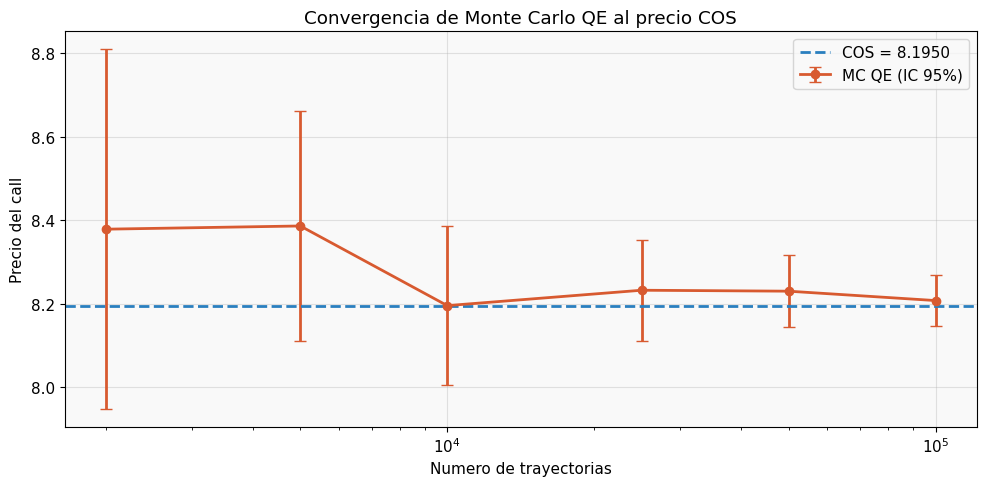

In [8]:
path_counts=[2000,5000,10000,25000,50000,100000]
precios=[]; errores=[]
for n in path_counts:
    p,s=heston_mc_qe(S0,K,r,tau,v0,kappa,theta,xi,rho,n_paths=n,n_steps=150,seed=11)
    precios.append(p); errores.append(s)

fig,ax=plt.subplots(figsize=(10,5))
ax.errorbar(path_counts,precios,yerr=1.96*np.array(errores),fmt='o-',
            color=ORANGE,capsize=4,label='MC QE (IC 95%)')
ax.axhline(p_cos,color=BLUE,ls='--',label=f'COS = {p_cos:.4f}')
ax.set_xscale('log'); ax.set_xlabel('Numero de trayectorias')
ax.set_ylabel('Precio del call'); ax.set_title('Convergencia de Monte Carlo QE al precio COS')
ax.legend()
plt.tight_layout(); plt.show()


## 6. Guía de selección de método

| Tarea | Método | Por qué |
|-------|--------|---------|
| Europea vainilla | COS | rápido, exacto, vectorizado |
| Calibración (muchos quotes) | COS | la velocidad es esencial |
| Un precio, robustez | Integral directa | simple, confiable |
| Path-dependent / exótico | QE Monte Carlo | única opción |
| Americana / ejercicio temprano | MC + regresión (LSM) | flexible |

**El flujo pragmático:** calibrar con COS (rápido). Una vez fijos los parámetros, priciar exóticos con QE Monte Carlo. Siempre cruzar-verificar ambos en una vainilla antes de confiar en cualquiera.


## 7. Revisión de código, explicación pedagógica y Q&A

### 7.2 Explicación pedagógica: COS y QE Monte Carlo, sin las matemáticas densas

Los tres métodos del notebook responden a la misma pregunta ("¿cuánto vale esta opción bajo Heston?") con estrategias muy distintas.

**Integración directa** es la versión honesta y literal: tomamos la fórmula teórica (una integral que va de 0 a infinito) y la evaluamos numéricamente, punto por punto, con un integrador adaptativo. Es simple y confiable — es el método que usamos como "árbitro" para verificar a los otros dos — pero cada opción individual requiere resolver esa integral desde cero. Cuando necesitas hacerlo miles de veces (como en cada evaluación de la función de pérdida durante una calibración), se vuelve lento — el problema que ya vivimos en las sesiones de calibración.

**El método COS** ataca ese problema de velocidad con una idea distinta: en vez de integrar sobre un rango infinito, reconstruye la curva de probabilidad usando muy pocas "piezas" de información — es la misma idea detrás de la compresión de una imagen o un audio (JPEG, MP3): con relativamente pocas frecuencias/coeficientes ya puedes reconstruir casi perfectamente algo suave, sin necesitar el detalle infinito. COS usa la función característica (que ya tenemos en forma cerrada) para calcular esos pocos coeficientes directamente, sin integración numérica abierta, y suma una serie corta (100-256 términos) para obtener el precio. El resultado: mismo nivel de precisión que la integración directa, pero muchísimo más rápido, y con un patrón de convergencia muy predecible (cada término extra reduce el error de forma exponencial — lo vimos en la gráfica de la Sección 2). Por eso es el motor ideal para calibración, donde la velocidad es la restricción principal.

El punto débil de COS, que descubrimos en la revisión de código: es tan bueno como la función característica que le des de insumo. Si esa función tiene un defecto (como el que encontramos), COS no lo delata — converge con total seguridad a un número, solo que equivocado. Es un recordatorio de que "rápido y con convergencia exponencial" no es lo mismo que "correcto"; hay que verificarlo contra un método de referencia en todo el rango que se piensa usar, no solo en un punto.

**Monte Carlo con esquema QE** ataca el problema desde otro ángulo completamente distinto: en vez de una fórmula, simula miles de futuros posibles del precio y la varianza, siguiendo la dinámica real de Heston paso a paso, y promedia el resultado — la definición literal de "precio = valor esperado descontado del payoff", sin necesitar ninguna fórmula cerrada. Es la única opción viable cuando el payoff depende de toda la trayectoria (barreras, asiáticas, cualquier exótico), algo que ni COS ni la integración directa pueden hacer, porque ambos solo entregan el precio de una opción europea simple a un vencimiento fijo.

El problema con la forma "obvia" de simular (discretizar la varianza ingenuamente): la varianza de Heston sigue un proceso de reversión a la media con raíz cuadrada (CIR), y un paso gaussiano ingenuo puede empujarla a valores negativos — algo que no tiene sentido y rompe la simulación en el siguiente paso (no puedes sacar raíz de un número negativo). No es un caso raro: lo vimos empíricamente, con parámetros que violan la condición de Feller (que es lo común en la práctica), la varianza se volvió negativa en ~10% de los pasos simulados. Los parches obvios (forzarla a cero, reflejarla) introducen un sesgo sistemático que no desaparece fácilmente.

QE resuelve esto sin parchar nada: en vez de fingir que el siguiente paso es gaussiano, reconoce que la distribución *exacta* de la siguiente varianza (dado el valor actual) sí se conoce (una chi-cuadrada no central), y la aproxima con una construcción que **nunca puede producir un número negativo**, ajustando los primeros dos momentos de esa distribución exacta según el "régimen" (varianza relativamente alta o cercana a cero). El resultado: simulaciones numéricamente sanas, fieles a la dinámica real de Heston, sin necesidad de absorción ni reflexión.

El costo de Monte Carlo (QE incluido) frente a COS/integración directa: es más lento y da una respuesta con incertidumbre estadística (un error estándar, no un número exacto), que además se reduce lentamente (a la mitad necesitas 4 veces más trayectorias). Por eso el flujo pragmático de la Sección 6 tiene sentido: COS para todo lo que sea vainilla/calibración (velocidad), Monte Carlo QE solo cuando el payoff realmente lo exige (exóticos, path-dependientes).

---

### 7.3 Preguntas de un alumno

**P1. En la Sección 2 y 5, la convergencia de COS y la comparación contra MC solo se muestran en $\tau=1$. ¿Probaron esto con vencimientos muy cortos o muy largos? Me preocupa que "COS siempre gana" no sea generalizable.**

Tenías toda la razón en desconfiar — lo probé y sí, hay un problema real (ver la sección 7.1 de arriba). COS coincide perfecto con la integración directa en $\tau=0.25, 0.5, 1$, pero empieza a divergir en $\tau=1.5$ y para $\tau=2$ ya difiere en ~37%, ambos siendo valores estables (no ruido numérico). La causa más probable es que la función característica que usa COS (`heston_cf_single`) no tiene la corrección "Little Trap" que sí tiene la de integración directa. La conclusión de la tabla de la Sección 6 ("COS: rápido, exacto, vectorizado") solo está demostrada para $\tau\approx1$ en este notebook — no se puede generalizar sin arreglar ese defecto y validar en todo el rango de vencimientos.

**P2. ¿Cómo se elige el intervalo $[a,b]$ de la expansión coseno? ¿Qué tan sensible es a que sea muy angosto o muy ancho?**

$[a,b]$ se centra en $c_1$ (el primer cumulante, aproximadamente la media del log-retorno) y se extiende $L\cdot\sqrt{|c_2|}$ hacia cada lado ($c_2$ es aproximadamente la varianza), con $L=12$ en este notebook — "media ± 12 desviaciones estándar", bastante generoso para una densidad razonablemente suave.

Si el intervalo es **demasiado angosto**: literalmente recortas parte de la densidad real fuera de la ventana, y la serie no puede "ver" esa masa faltante — el resultado es un precio sesgado de forma sistemática (típicamente subestima lo que depende de las colas, como opciones OTM), y ese sesgo **no se arregla agregando más términos $N$**, porque el problema es la ventana, no la resolución dentro de ella. Si es **demasiado ancho**: no pierdes exactitud en principio, pero pagas en eficiencia — los mismos $N$ términos ahora tienen que cubrir un rango más amplio, así que cada término representa una resolución de frecuencia más burda, y necesitarías un $N$ mayor para recuperar la misma convergencia exponencial. Vale la pena investigar si las fórmulas de $c_1,c_2$ mismas son parte del problema detectado en la P1, además de la función característica sin corregir.

**P3. ¿De dónde sale $\psi_c=1.5$ en el esquema QE? ¿Es universal o depende de los parámetros?**

Es una constante práctica que Andersen (2008) recomienda como buen punto de corte, no algo que se re-derive de tus parámetros específicos de Heston — el paper muestra que el esquema funciona bien con $\psi_c$ en un rango aproximado de 1 a 2, y 1.5 es su default sugerido. Lo que sí depende de tus parámetros (y del estado actual de la simulación) es $\psi=s^2/m^2$ en cada paso — así que qué tan seguido se usa la rama cuadrática vs. la exponencial sí varía mucho según qué tan lejos estés de cumplir Feller, pero el umbral 1.5 en sí es fijo por convención, no un parámetro del modelo.

**P4. La demostración de que Euler falla solo cuenta varianzas negativas (~10%). ¿Cuánto sesgo real en precio introduce eso comparado con QE?**

Buena observación — el notebook no lo calcula, solo cuenta el síntoma (varianza negativa), no el efecto final en el precio. La intuición: la absorción ($v\to\max(v,0)$) empuja sistemáticamente la trayectoria de varianza hacia arriba respecto al proceso verdadero (las excursiones negativas se "reflejan" a cero en vez de dejarlas revertir naturalmente), lo cual también sesga el precio vía el término de correlación $\rho$. Ese sesgo crece con qué tan seguido tocas la frontera (ya sabemos que es frecuente, ~10% de los pasos aquí) y con el tamaño del paso $\Delta t$ — Euler parchado solo converge al precio verdadero en el límite de pasos infinitos, mientras que QE es preciso incluso con relativamente pocos pasos porque ajusta los momentos de la distribución exacta en cada paso, no un incremento gaussiano lineal. Para ponerle un número real, correrías Euler-con-absorción y QE contra la misma referencia (COS o integración directa) variando `n_steps`, y verías que QE se acerca a la referencia mucho más rápido — un buen ejercicio de tarea que este notebook no incluye todavía.

**P5. ¿QE necesita un truco tipo "Little Trap", o el hecho de que nunca sea negativa por construcción significa que no tiene ningún problema numérico análogo?**

No es exactamente lo mismo, porque son familias de métodos distintas. El "Little Trap" es un problema específico de **números complejos** — ramas del logaritmo complejo en la función característica — y QE no usa números complejos en ningún punto de su simulación (es álgebra real de principio a fin), así que ese problema en particular simplemente no le aplica. Eso no significa que QE esté libre de cualquier cuidado numérico: cerca de $\psi=\psi_c$ el cambio entre ramas puede introducir una pequeña discontinuidad si no se maneja con cuidado (Andersen lo discute en el paper), y los pisos `1e-12` que ves repetidos en el código (`np.maximum(m**2,1e-12)`, etc.) existen precisamente para evitar divisiones entre cero o logaritmos de cero en casos extremos. Son cuidados numéricos de una naturaleza distinta a la trampa del logaritmo complejo, no el mismo problema disfrazado.

**P6. Si COS es tan rápido, ¿por qué no lo usamos para calibrar en las sesiones 4 y 5?**

Porque ahí usamos `heston_call` construido sobre `heston_prob_j`/`heston_cf_j` — la integración directa con Little Trap ya corregido —, no COS; COS se introduce por primera vez en este notebook. Y dado lo que encontramos en la P1 (COS sin validar más allá de $\tau=1$, con un defecto real a partir de $\tau\approx1.5$-2), habría sido arriesgado meterlo tal cual al loop de calibración de Calibración II, que usó vencimientos hasta 2 años. No hay una razón teórica profunda para evitar COS en calibración — de hecho, la Sección 6 tiene toda la razón en que la velocidad es justo lo que se necesita ahí —, pero sí una razón muy concreta y práctica descubierta en este mismo notebook: no metas un motor de pricing más rápido a un loop de calibración sin antes validarlo en todo tu rango objetivo de vencimientos.

**P7. ¿Cuántos caminos hacen falta en la práctica para que el error estándar de QE sea "aceptable"?**

No hay un número universal — depende de qué tan preciso necesites ser en relación al spread bid-ask del instrumento que estés priciando o cubriendo. Como el error estándar de Monte Carlo cae como $1/\sqrt{n_{caminos}}$, para reducirlo a la mitad necesitas 4 veces más caminos — rendimientos decrecientes rápido, por lo que en producción se prefiere reducción de varianza (variables antitéticas, variables de control —frecuentemente usando el precio analítico/COS de una vainilla similar—, muestreo por importancia) en vez de solo aumentar `n_paths` a lo bruto. Regla práctica: el intervalo de confianza de tu MC debería ser cómodamente más chico que la mitad del spread bid-ask del instrumento. En el ejemplo del notebook (100,000 caminos, 200 pasos), el error estándar fue 0.03 sobre un precio de 8.18 — una precisión relativa de ~0.4%, ya más ajustada que la mayoría de los spreads reales de vainillas líquidas, así que esa configuración ya es "suficientemente buena" para una prueba de sanidad; para algo que realmente vayas a operar o cubrir (sobre todo exóticos, donde QE es la herramienta principal), conviene además verificar convergencia empíricamente (como en la gráfica de la Sección 5) y considerar reducción de varianza en vez de solo más caminos.

**P8. ¿Qué tan robusta es la forma "Little Trap" en general — podría reaparecer el problema de "branch cutting" en alguna región no probada aquí?**

Sí, potencialmente, aunque la corrección empuja la "zona de peligro" mucho más lejos. El problema clásico ocurre porque la función característica involucra un logaritmo complejo, y el argumento de ese logaritmo puede "dar la vuelta" al origen conforme crece $\tau$ o con ciertas combinaciones de parámetros, haciendo que la rama principal del logaritmo salte de forma discontinua. La corrección Little Trap ($\tilde g=1/g$, con el signo correspondiente) está diseñada específicamente para mantener $|\tilde g|<1$ en un rango mucho más amplio de parámetros y vencimientos que la forma ingenua — por eso `heston_cf_j` aguantó bien hasta $\tau=2$ en mis pruebas mientras que la versión sin corregir de COS ya había fallado ahí. Pero "mucho más amplio" no es "sin límite": para combinaciones suficientemente extremas (vencimientos muy largos junto con $\xi$ alto y $\rho$ cercano a $\pm1$) hasta la forma corregida puede tener problemas numéricos (de hecho, en mis pruebas con $\tau$ muy grande vi desbordamientos numéricos en $\exp(d\cdot\tau)$). La lección de fondo, otra vez: "robusto" debería significar "validado empíricamente en el rango real de strikes/vencimientos/parámetros que vas a usar", no "correcto por diseño y ya".